# PID Control

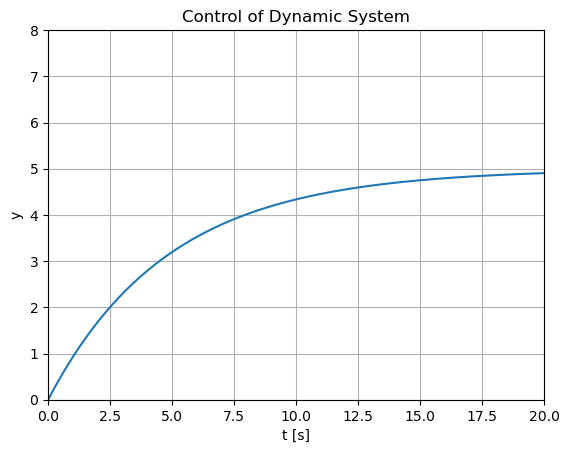

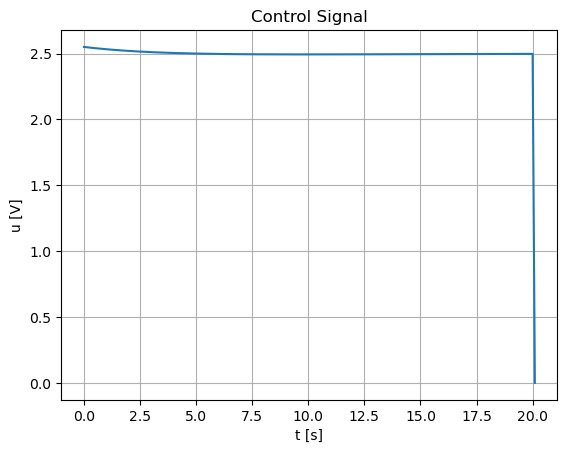

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Model Parameters
K = 2
T = 5
a = -(1/T)
b = K/T

# Simulation Parameters
Ts = 0.1 # Sampling Time
Tstop = 20 # End of Simulation Time
N = int(Tstop/Ts) # Simulation length
y = np.zeros(N+2) # Initialization the Tout vector
y[0] = 0 # Initial Vaue

# PI Controller Settings
Kp = 0.5
Ti = 5

r = 5 # Reference value
e = np.zeros(N+2) # Initialization
u = np.zeros(N+2) # Initialization

# Simulation
for k in range(N+1):
    e[k] = r - y[k]
    u[k] = u[k-1] + Kp*(e[k] - e[k-1]) + (Kp/Ti)*Ts*e[k]
    y[k+1] = (1+Ts*a)*y[k] + Ts*b*u[k]

# Plot the Simulation Results
t = np.arange(0,Tstop+2*Ts,Ts) #Create the Time Series

# Plot Process Value
plt.figure(1)
plt.plot(t,y)

# Formatting the appearance of the Plot
plt.title('Control of Dynamic System')
plt.xlabel('t [s]')
plt.ylabel('y')
plt.grid()
xmin = 0
xmax = Tstop
ymin = 0
ymax = 8
plt.axis([xmin, xmax, ymin, ymax])
plt.show()

# Plot Control Signal
plt.figure(2)
plt.plot(t,u)

# Formatting the appearance of the Plot
plt.title('Control Signal')
plt.xlabel('t [s]')
plt.ylabel('u [V]')
plt.grid()

# Stability Analysis

Hp(s) = <TransferFunction>: sys[39]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


   2
-------
5 s + 1

Hc(s) = <TransferFunction>: sys[40]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


0.8 s + 0.4
-----------
    2 s

Hm(s) = <TransferFunction>: sys[41]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


  1
-----
s + 1

Hf(s) = <TransferFunction>: sys[42]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


  1
-----
s + 1

L(s) = <TransferFunction>: sys[45]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


         1.6 s + 0.8
------------------------------
10 s^4 + 22 s^3 + 14 s^2 + 2 s

T(s) = <TransferFunction>: sys[47]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


             1.6 s + 0.8
--------------------------------------
10 s^4 + 22 s^3 + 14 s^2 + 3.6 s + 0.8

poles =  [-1.29923223+0.j         -0.69808768+0.j         -0.10134005+0.27916877j
 -0.10134005-0.27916877j]
wc = 0.26 rad/s
w180 = 0.71 rad/s
GM = 5.62
GM = 15.00 dB
PM = 36.10 deg
Kc = 2.25


C:\Users\HP\anaconda3\Lib\site-packages\control\config.py:363: FutureWarning: keyword 'margins' is deprecated; use 'display_margins'
  warnings.warn(


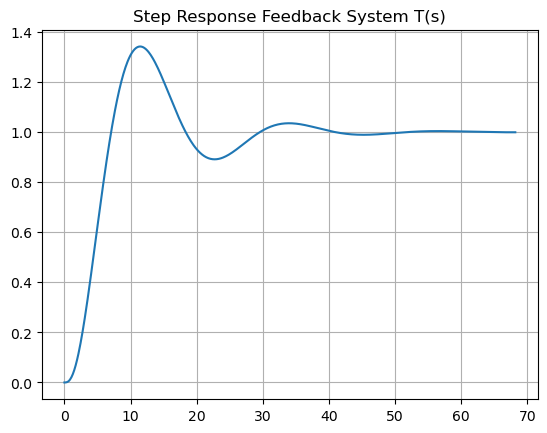

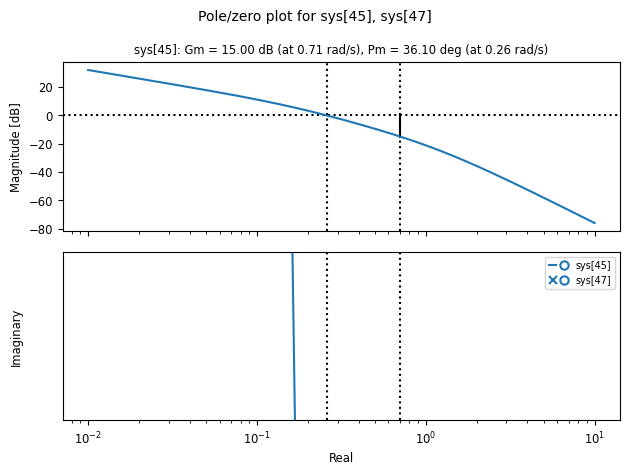

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import control

# Transfer Function Process
K = 2; T = 5
num_p = np.array ([K])
den_p = np.array ([T , 1])
Hp = control.tf(num_p , den_p)
print ('Hp(s) =', Hp)

# Transfer Function PI Controller
Kp = 0.4
Ti = 2
num_c = np.array ([Kp*Ti, Kp])
den_c = np.array ([Ti , 0])
Hc = control.tf(num_c, den_c)
print ('Hc(s) =', Hc)

# Transfer Function Measurement
Tm = 1
num_m = np.array ([1])
den_m = np.array ([Tm , 1])
Hm = control.tf(num_m , den_m)
print ('Hm(s) =', Hm)

# Transfer Function Lowpass Filter
Tf = 1
num_f = np.array ([1])
den_f = np.array ([Tf , 1])
Hf = control.tf(num_f , den_f)
print ('Hf(s) =', Hf)

# The Loop Transfer function
L = control.series(Hc, Hp, Hf, Hm)
print ('L(s) =', L)

# Tracking transfer function
T = control.feedback(L,1)
print ('T(s) =', T)

# Step Response Feedback System (Tracking System)
t, y = control.step_response(T)
plt.figure(1)
plt.plot(t,y)
plt.title("Step Response Feedback System T(s)")
plt.grid()

# Bode Diagram with Stability Margins
plt.figure(2)
control.bode(L, dB=True, deg=True, margins=True)

# Poles and Zeros
control.pzmap(T)
p = control.poles(T)
z = control.zeros(T)
print("poles = ", p)

# Calculating stability margins and crossover frequencies
gm , pm , w180 , wc = control.margin(L)

# Convert gm to Decibel
gmdb = 20 * np.log10(gm)

print("wc =", f'{wc:.2f}', "rad/s")
print("w180 =", f'{w180:.2f}', "rad/s")

print("GM =", f'{gm:.2f}')
print("GM =", f'{gmdb:.2f}', "dB")
print("PM =", f'{pm:.2f}', "deg")

# Find when Sysem is Marginally Stable (Kritical Gain - Kc)
Kc = Kp*gm
print("Kc =", f'{Kc:.2f}')